## Chapter 1: Data extraction

#### Imports

In [1]:
import pandas as pd
import osmnx as ox
import geopandas as gpd
import re
from pathlib import Path
import requests
from bs4 import BeautifulSoup
import json
import time
from shapely.geometry import Point
from shapely import wkt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import h3
from shapely.geometry import Polygon

#### Metro stations [OSM]

In [111]:
metro_stations = ox.features_from_place("Warsaw, Poland", tags={"railway": "station", "station": "metro"})

metro_stations = metro_stations[metro_stations["network"].isin(["Warsaw Metro", "Metro Warszawskie"])][["name", "geometry"]]

gdf_metro = gpd.GeoDataFrame(metro_stations, geometry="geometry", crs="EPSG:4326")

gdf_metro.head()

name                   geometry
element id                                                  
node    35121250   Ratusz-Arsenał  POINT (21.00088 52.24522)
        291414851        Marymont  POINT (20.97194 52.27158)
        307389114   Stare Bielany  POINT (20.94935 52.28183)
        307389115      Wawrzyszew  POINT (20.93952 52.28635)
        307389116         Młociny  POINT (20.92987 52.29077)

#### University buildings [Handpicked buildings from OSM]

There is a big amount of buildings presented in OSM that are somehow related to universities / parts of the universities' infrastructures, but no sufficient type of filtering the exact dataset needed. Hence, for this project university buildings were selected manually.

In [ ]:
universities = ox.features_from_place("Warsaw, Poland", tags={'amenity': ['university'], 'building': ['university']})
mapping = pd.read_csv("universities_map.csv")

gdf_universities = gpd.GeoDataFrame(universities, geometry="geometry", crs="EPSG:4326")

gdf_universities = gdf_universities[["name", "geometry"]]
gdf_universities["latitude"] = gdf_universities.geometry.centroid.y
gdf_universities["longitude"] = gdf_universities.geometry.centroid.x

# mapping universities, using building names to find coordinates
results = []
not_found = []

for _, map_row in mapping.iterrows():
    university  = map_row["university"]
    bname       = map_row["building_name"]
    is_main     = map_row["is_main"]

    matches = gdf_universities[gdf_universities["name"] == bname]

    if matches.empty:
        not_found.append((university, bname))
        continue

    lat = matches["latitude"].mean()
    lon = matches["longitude"].mean()

    results.append({
        "university":    university,
        "building_name": bname,
        "is_main":       is_main,
        "latitude":      round(lat, 7),
        "longitude":     round(lon, 7),
    })

gdf_universities = pd.DataFrame(results)

gdf_universities["_sort"] = gdf_universities["is_main"].map({True: 0, False: 1})
gdf_universities = (gdf_universities
                     .sort_values(["university", "_sort", "building_name"])
                     .drop(columns="_sort")
                     .reset_index(drop=True))

gdf_universities = gpd.GeoDataFrame(gdf_universities[["university", "building_name", "is_main"]], geometry=gpd.points_from_xy(gdf_universities.longitude, gdf_universities.latitude), crs="EPSG:4326")

print(f"Map entries:  {len(mapping)} rows across "
      f"{mapping['university'].nunique()} universities")

gdf_universities.head()

C:\Users\PlaySpace\AppData\Local\Temp\ipykernel_5308\655733835.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_universities["latitude"] = gdf_universities.geometry.centroid.y
C:\Users\PlaySpace\AppData\Local\Temp\ipykernel_5308\655733835.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_universities["longitude"] = gdf_universities.geometry.centroid.x


Map entries:  161 rows across 20 universities


,university,building_name,is_main,geometry
0,Akademia Finansów i Biznesu Vistula,Akademia Finansów i Biznesu Vistula,True,POINT (21.03397 52.15882)
1,Akademia Leona Koźmińskiego,Akademia Leona Koźmińskiego,True,POINT (21.01395 52.2715)
2,Akademia Pedagogiki Specjalnej,Akademia Pedagogiki Specjalnej im. Marii Grzeg...,True,POINT (20.96993 52.21718)
3,Akademia Pedagogiki Specjalnej,Instytut Edukacji Artystycznej Akademii Pedago...,False,POINT (20.98386 52.22249)
4,Akademia Pożarnicza,Akademia Pożarnicza,True,POINT (20.97658 52.27198)


#### Dorms [Extracted using a Perplexity prompt]

Dorms dataset had to be pulled by searching for each student living individually, mostly on the official university websites. So, the capability of Perplexity to search and aggregate information available on Google for relevant information has been utilized.

In [113]:
dorms = pd.read_csv("warsaw_dorms.csv")

gdf_dorms = gpd.GeoDataFrame(dorms[["dorm_name", "university"]], geometry=gpd.points_from_xy(dorms.longitude, dorms.latitude), crs="EPSG:4326")

gdf_dorms.head()

,dorm_name,university,geometry
0,"DS1 ""Muchomorek""",Uniwersytet Warszawski,POINT (20.9813 52.2115)
1,"DS2 ""Żwirek""",Uniwersytet Warszawski,POINT (20.981 52.2118)
2,"DS3 ""Kic""",Uniwersytet Warszawski,POINT (21.0856 52.2386)
3,"DS4 ""Zamenhof""",Uniwersytet Warszawski,POINT (21.0018 52.2498)
4,"DS5 ""Smyczkowa""",Uniwersytet Warszawski,POINT (21.0282 52.1763)


#### Districts [https://github.com/andilabs/warszawa-dzielnice-geojson]

In [114]:
gdf_districts = gpd.read_file("warszawa-dzielnice.geojson")

gdf_districts = gdf_districts[gdf_districts["name"] != "Warszawa"].to_crs("EPSG:4326")[gdf_districts["name"] != "Warszawa"]

gdf_districts["district_name"] = gdf_districts["name"]
gdf_districts = gdf_districts[["district_name", "geometry"]]

gdf_districts.head()

c:\Users\PlaySpace\anaconda3\envs\islp\Lib\site-packages\geopandas\geodataframe.py:1891: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


,district_name,geometry
1,Ochota,"MULTIPOLYGON (((21.00152 52.22807, 20.99059 52..."
2,Rembertów,"MULTIPOLYGON (((21.13242 52.23909, 21.13313 52..."
3,Bemowo,"MULTIPOLYGON (((20.87309 52.21666, 20.87307 52..."
4,Białołęka,"MULTIPOLYGON (((20.99622 52.28734, 20.99782 52..."
5,Wesoła,"MULTIPOLYGON (((21.26173 52.21007, 21.26059 52..."


#### Bus and Tram stops [Overpass for OSM]

In [ ]:
bbox = '52.09,20.85,52.37,21.27'
overpass_url = "http://overpass-api.de/api/interpreter"

# fetching bus stops and tram stops with separate queries to ensure we get all relevant tags
bus_query = f'''
[out:json][timeout:60];
(
  node["highway"="bus_stop"]({bbox});
  node["public_transport"="platform"]["bus"="yes"]({bbox});
  way["highway"="bus_stop"]({bbox});
  node["public_transport"="stop_position"]["bus"="yes"]({bbox});
);
out center;
'''

r_bus = requests.get(overpass_url, params={'data': bus_query})
bus_data = r_bus.json()['elements']

tram_query = f'''
[out:json][timeout:60];
(
  node["railway"="tram_stop"]({bbox});
  node["public_transport"="platform"]["tram"="yes"]({bbox});
  node["public_transport"="stop_position"]["tram"="yes"]({bbox});
);
out center;
'''

r_tram = requests.get(overpass_url, params={'data': tram_query})
tram_data = r_tram.json()['elements']

# converting bus and tram data to geodataframes
def elements_to_gdf(elements):
    data = []
    for el in elements:
        if 'lat' in el and 'lon' in el:
            lat, lon = el['lat'], el['lon']
        elif 'center' in el:
            lat, lon = el['center']['lat'], el['center']['lon']
        else:
            continue
        data.append({
            'id': el['id'],
            'name': el.get('tags', {}).get('name', ''),
            'ref': el.get('tags', {}).get('ref', ''),
            'operator': el.get('tags', {}).get('operator', ''),
            'lat_r': round(lat, 4),
            'lon_r': round(lon, 4),
            'geometry': Point(lon, lat)
        })
    gdf = gpd.GeoDataFrame(data, geometry='geometry', crs="EPSG:4326")
    gdf = gdf.drop_duplicates(subset=['lat_r', 'lon_r']).drop(columns=['lat_r', 'lon_r'])
    return gdf

gdf_bus = elements_to_gdf(bus_data)
gdf_tram = elements_to_gdf(tram_data)
gdf_transport = pd.concat([gdf_bus, gdf_tram], ignore_index=True)
gdf_transport.head()

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
gdf_bus = gpd.GeoDataFrame(pd.read_csv("warsaw_bus_stops.csv"))
gdf_tram = gpd.GeoDataFrame(pd.read_csv("warsaw_tram_stops.csv"))

gdf_transport = pd.concat([gdf_bus, gdf_tram], ignore_index=True)
gdf_transport["geometry"] = gdf_transport["geometry"].apply(wkt.loads)
gdf_transport = gpd.GeoDataFrame(gdf_transport, geometry="geometry", crs="EPSG:4326")
gdf_transport.head()

,id,name,ref,operator,geometry
0,27166844,Objazdowa 02,229202,NaN,POINT (21.21102 52.22411)
1,27166890,Edisona 02,201702,NaN,POINT (21.13687 52.2299)
2,27166928,CH Promenada 02,210302,NaN,POINT (21.10813 52.23348)
3,27167673,Krakowiaków 05,401205,NaN,POINT (20.95513 52.18558)
4,31156649,PKP Koło 05,506905,NaN,POINT (20.95753 52.24665)


#### Listings [Scraped from https://www.otodom.pl]

Decision of filtering the listings to 1-2 room appartments only on the scraping stage is justified mostly by the fact that normally 3+ room flats are too expensive for students, compared to the normal "Student budget". "Student budget" is used as a refference and will be, further in the analysis and score creation.

In [ ]:
BASE_URL = "https://www.otodom.pl/pl/oferty/wynajem/mieszkanie/warszawa"
HEADERS = {"User-Agent": "Mozilla/5.0"}

# helper functions to parse numbers from strings
def _parse_number(value) -> float | None:
    if value is None:
        return None
    cleaned = str(value).replace("\xa0", "").replace(" ", "")
    m = re.search(r"\d+\.?\d*", cleaned)
    return float(m.group()) if m else None

def _parse_int(value) -> int | None:
    n = _parse_number(value)
    return int(n) if n is not None else None

# scrape the list page to get basic info and URLs for details, uses __NEXT_DATA__ JSON embedded in the page for more reliable data extraction
def scrape_list_page(page: int) -> list:
    url = f"{BASE_URL}?page={page}"
    response = requests.get(url, headers=HEADERS)
    soup = BeautifulSoup(response.text, "html.parser")

    script_tag = soup.find("script", {"id": "__NEXT_DATA__"})
    if not script_tag:
        print(f"No __NEXT_DATA__ for page {page}")
        return []

    data = json.loads(script_tag.string)

    try:
        offers = data["props"]["pageProps"]["data"]["searchAds"]["items"]
    except KeyError:
        return []

    results = []
    for offer in offers:
        slug = offer.get("slug", "")
        if not slug:
            continue

        # construct full URL based on slug format
        if slug.startswith("/"):
            full_url = "https://www.otodom.pl" + slug
        elif slug.startswith("http"):
            full_url = slug
        else:
            full_url = "https://www.otodom.pl/pl/oferta/" + slug

        # parse rooms, which can be in various formats (e.g. "TWO", "2", or even "2.5")
        rooms_raw = offer.get("roomsNumber")
        rooms_map = {
            "ONE": 1, "TWO": 2, "THREE": 3, "FOUR": 4,
            "FIVE": 5, "SIX": 6, "SEVEN": 7, "EIGHT": 8,
            "NINE": 9, "TEN": 10,
        }
        if isinstance(rooms_raw, str):
            rooms = rooms_map.get(rooms_raw.upper(), _parse_int(rooms_raw))
        else:
            rooms = rooms_raw

        rent_price_block = offer.get("rentPrice") or {}
        czynsz = rent_price_block.get("value")

        results.append({
            "title":  offer.get("title"),
            "url":    full_url,
            "rooms":  rooms,
            "czynsz": czynsz,
        })

    return results

# extract detailed data from the listing page, tries to use structured data (JSON-LD) if available, otherwise falls back to __NEXT_DATA__ JSON embedded in the page
def extract_listing_data(url: str):
    try:
        response = requests.get(url, headers=HEADERS)
        soup = BeautifulSoup(response.text, "html.parser")

        # first try to find structured data in JSON-LD format, which is more reliable and less likely to break if the page layout changes
        ld_tag = soup.find("script", {"type": "application/ld+json"})
        if ld_tag:
            ld = json.loads(ld_tag.string)
            graph = ld.get("@graph", [ld])

            for node in graph:
                node_types = node.get("@type", [])
                if isinstance(node_types, str):
                    node_types = [node_types]
                
                if "Apartment" in node_types or "Product" in node_types:
                    geo          = node.get("geo", {})
                    address      = node.get("address", {})
                    offers_block = node.get("offers", {})

                    # additional properties like area and rooms can be in various formats, so we look for them in the "additionalProperty" list
                    props = {
                        p["name"]: p["value"]
                        for p in node.get("additionalProperty", [])
                        if "name" in p and "value" in p
                    }

                    area  = _parse_number(props.get("Powierzchnia"))

                    rooms = node.get("numberOfRooms")
                    if rooms is None:
                        rooms = _parse_int(props.get("Liczba pokoi"))

                    czynsz = _parse_number(props.get("Czynsz"))

                    return {
                        "price":     offers_block.get("price"),
                        "currency":  offers_block.get("priceCurrency", "PLN"),
                        "area":      area,
                        "rooms":     rooms,
                        "czynsz":    czynsz,
                        "latitude":  geo.get("latitude"),
                        "longitude": geo.get("longitude"),
                        "city":      address.get("addressLocality"),
                        "district":  address.get("addressRegion"),
                        "street":    address.get("streetAddress"),
                    }

        script_tag = soup.find("script", {"id": "__NEXT_DATA__"})
        if not script_tag:
            print("No data for:", url)
            return None

        data     = json.loads(script_tag.string)
        ad       = data["props"]["pageProps"]["ad"]
        target   = ad.get("target", {})
        location = ad.get("location", {})
        coords   = location.get("coordinates", {})
        addr     = location.get("address", {})

        # czynsz can be in a separate field or part of the rent price, and can be a number or a dict with more details, so we handle multiple cases
        czynsz_raw = target.get("Czynsz_dodatki") or target.get("Czynsz")
        if isinstance(czynsz_raw, dict):
            czynsz = czynsz_raw.get("value")
        else:
            czynsz = _parse_number(czynsz_raw)

        return {
            "price":     _parse_number(target.get("Price")),
            "currency":  "PLN",
            "area":      _parse_number(target.get("Area")),
            "rooms":     _parse_int(target.get("Rooms_num")),
            "czynsz":    czynsz,
            "latitude":  coords.get("latitude"),
            "longitude": coords.get("longitude"),
            "city":      addr.get("city"),
            "district":  addr.get("district"),
            "street":    addr.get("street"),
        }

    except Exception as e:
        print("Error for:", url, e)
        return None

# since some info like rooms and czynsz can be missing from the details but present in the list page, we merge them to fill in gaps
def _merge(detail: dict, list_row: dict) -> dict:
    if detail.get("rooms") is None and list_row.get("rooms") is not None:
        detail["rooms"] = list_row["rooms"]
    if detail.get("czynsz") is None and list_row.get("czynsz") is not None:
        detail["czynsz"] = list_row["czynsz"]
    return detail

# main function to run the scraper, collects listings from multiple pages, extracts details, and compiles everything into a DataFrame with some additional processing
def run_scraper(pages: int = 3, max_listings: int = 100) -> pd.DataFrame:
    listings = []

    for page in range(1, pages + 1):
        print(f"Scraping page {page}")
        listings.extend(scrape_list_page(page))
        time.sleep(1)

    df_urls = pd.DataFrame(listings).drop_duplicates(subset=["url"])
    print(f"Found {len(df_urls)} listings")
    df_urls = df_urls.head(max_listings)

    details = []
    for i, row in df_urls.iterrows():
        print(f"{i + 1}/{len(df_urls)}  {row['url']}")
        data = extract_listing_data(row["url"])
        if data:
            data = _merge(data, row.to_dict())
            data["url"]   = row["url"]
            data["title"] = row["title"]
            details.append(data)
        time.sleep(1)

    print(f"Collected details: {len(details)}")

    if not details:
        print("No details collected")
        return pd.DataFrame()

    final_df = pd.DataFrame(details)

    required = [c for c in ["price", "area", "latitude", "longitude"]
                if c in final_df.columns]
    final_df = final_df.dropna(subset=required)

    # filter to 1-2 rooms if that column exists, since that's our target segment and also helps remove outliers with very high prices
    if "rooms" in final_df.columns:
        before = len(final_df)
        final_df = final_df[final_df["rooms"] <= 2]
        print(f"Filtered to 1-2 rooms: {len(final_df)} / {before} listings kept")

    if not final_df.empty:
        final_df["price_per_m2"] = final_df["price"] / final_df["area"]

        if "czynsz" in final_df.columns:
            final_df["total_monthly"] = (
                final_df["price"] + final_df["czynsz"].fillna(0)
            )
    col_order = [
        "title", "url",
        "price", "czynsz", "total_monthly",
        "area", "rooms", "price_per_m2",
        "city", "district", "street",
        "latitude", "longitude", "currency",
    ]
    existing = [c for c in col_order if c in final_df.columns]
    final_df = final_df[existing]

    return final_df

if __name__ == "__main__":
    df = run_scraper(pages=1, max_listings=10)

    #if not df.empty:
        #df.to_csv("warsaw_rent_clean.csv", index=False)
        #print(f"\nSaved {len(df)} rows in warsaw_rent_clean.csv")
    #else:
        #print("No data")

Scraping page 1
Found 36 listings
1/10  https://www.otodom.pl/pl/oferta/mieszkanie-w-sercu-woli-ID4AHXi
2/10  https://www.otodom.pl/pl/oferta/piekna-mokotowska-2-pokoje-po-generalnym-remoncie-top-lokalizacja-ID4ACfL
3/10  https://www.otodom.pl/pl/oferta/mieszkanie-2-pokoje-po-remoncie-metro-wierzbno-ID4wljN
4/10  https://www.otodom.pl/pl/oferta/44m2-klimatyzacja-miasteczko-wilanow-ID4ASsq
5/10  https://www.otodom.pl/pl/oferta/przestronne-idealne-dla-rodziny-90m2-ID4wfNl
6/10  https://www.otodom.pl/pl/oferta/kamienica-miejsce-postojowe-lazienki-ID4zIpX
7/10  https://www.otodom.pl/pl/oferta/bezposrednio-sloneczne-3-pokoje-78m-parking-internet-tv-w-cenie-ID4AT46
8/10  https://www.otodom.pl/pl/oferta/ladne-1-pokojowe-mieszkanie-30m-na-zielonym-powislu-ID3EfpC
9/10  https://www.otodom.pl/pl/oferta/2-pokoje-balkon-blisko-metra-mokotow-ID4ABvU
10/10  https://www.otodom.pl/pl/oferta/dla-pary-singla-dobra-komunikacja-balkon-ID4AIdG
Collected details: 10
Filtered to 1-2 rooms: 6 / 10 listings ke

(*using an extract scraped previously as an example*)

In [137]:
df = pd.read_csv("warsaw_rent_clean_2903.csv")

## Chapter 2: Dataset creation

#### Czynsz estimation

Czynsz fee or exploitation cost has to be considered or estimated when calculating the appartments' price in Poland, as it is normally paid monthly, as an addition to rent payment.

In [ ]:
MIN_SAMPLES = 5

# we will impute missing czynsz values using a hierarchical approach: first by district+rooms, then by rooms, and finally using the overall median if needed
reported = df[df["czynsz"].notna()].copy()

l1 = (
    reported[reported["czynsz"] > 0]
    .groupby(["district", "rooms"])["czynsz"]
    .agg(median="median", count="count")
    .reset_index()
)
l1_valid = l1[l1["count"] >= MIN_SAMPLES].set_index(["district", "rooms"])["median"]

l2 = (
    reported[reported["czynsz"] > 0]
    .groupby("rooms")["czynsz"]
    .agg(median="median", count="count")
    .reset_index()
)
l2_valid = l2[l2["count"] >= MIN_SAMPLES].set_index("rooms")["median"]

l3 = reported.loc[reported["czynsz"] > 0, "czynsz"].median()

print(f"Level 3 median: {l3:.0f} PLN")

def impute_row(row):
    if pd.notna(row["czynsz"]) and row["czynsz"] > 0:
        return row["czynsz"], "original"

    district = row.get("district")
    rooms    = row.get("rooms")
    
    if pd.notna(district) and pd.notna(rooms):
        key = (district, rooms)
        if key in l1_valid.index:
            return l1_valid[key], "district+rooms"

    if pd.notna(rooms) and rooms in l2_valid.index:
        return l2_valid[rooms], "rooms"

    return l3, "overall"

results = df.apply(impute_row, axis=1, result_type="expand")
results.columns = ["czynsz_imputed", "czynsz_source"]

df = pd.concat([df, results], axis=1)

df["total_monthly"] = df["price"] + df["czynsz_imputed"]

print(f"\n{df['czynsz_source'].value_counts().to_string()}")

Level 3 median: 750 PLN

czynsz_source
original          1159
district+rooms     158


#### Filtering for only 1-2 room appartments with valid coordinates available

In [139]:
df = df[["title", "total_monthly", "area", "rooms", "price_per_m2", "latitude", "longitude", "url"]].dropna(subset=["latitude", "longitude"])
df = df[(df["latitude"] != 0) & (df["longitude"] != 0)][(df["rooms"] <= 2)]

gdf_listings = gpd.GeoDataFrame(df[["title", "total_monthly", "area", "rooms", "price_per_m2", "url"]], geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

gdf_listings = gdf_listings[(gdf_listings.geometry.x.between(20.8, 21.3)) & (gdf_listings.geometry.y.between(52.1, 52.4))]

gdf_listings.head()

,title,total_monthly,area,rooms,price_per_m2,url,geometry
0,"Przestronna kawalerka, metro Dworzec Gdański",3900.0,38.0,2,81.578947,https://www.otodom.pl/pl/oferta/przestronna-ka...,POINT (20.99358 52.2569)
1,"Nowoczesna duża kawalerka, ul. Szeligowska, Be...",3770.0,33.0,1,96.969697,https://www.otodom.pl/pl/oferta/nowoczesna-duz...,POINT (20.88063 52.22795)
2,Mieszkania WARSZAWA dla studentów oraz młodych...,3550.0,20.0,1,147.500000,https://www.otodom.pl/pl/oferta/mieszkania-war...,POINT (21.0064 52.25903)
3,Nowe mieszkanie 2 zamykane pokoje oddzielna ku...,3770.0,44.1,2,70.294785,https://www.otodom.pl/pl/oferta/nowe-mieszkani...,POINT (20.88502 52.22757)
4,"2 pok., wyposażone, klimatyzacja, TV, garaż, u...",4300.0,40.0,2,90.000000,https://www.otodom.pl/pl/oferta/2-pok-wyposazo...,POINT (20.88932 52.22749)


#### Insight 1: Rooms parameter and real flat area relationship

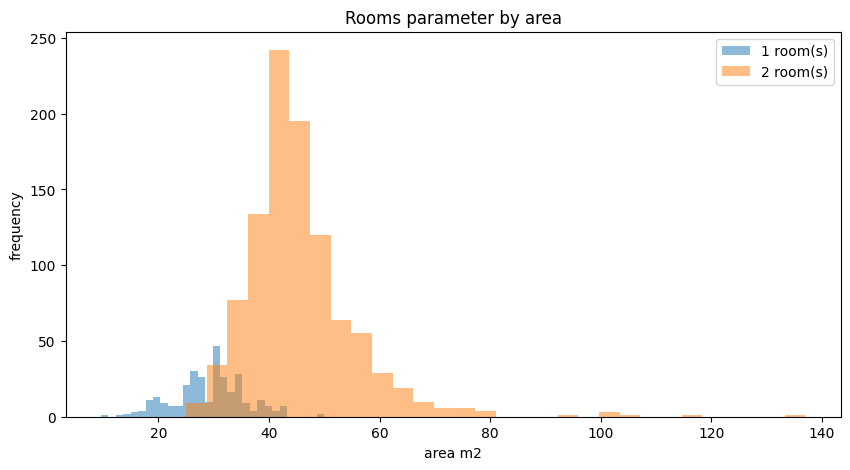

In [124]:
fig, ax = plt.subplots(figsize=(10, 5))
for rooms, group in gdf_listings.groupby("rooms"):
    ax.hist(group["area"], bins=30, alpha=0.5, label=f"{rooms} room(s)")
ax.set_title("Rooms parameter by area", fontsize=12)
ax.set_xlabel("area m2")
ax.set_ylabel("frequency")
ax.legend()
plt.show()

On the graph, we can clearly observe a massive overlap between so-called "1" and "2-room" appartments. Visual suggests that we can not judge on the flat shareability or size just based on the "rooms" parameter.

In [125]:
one_room = gdf_listings[gdf_listings["rooms"] == 1]["area"]
two_room = gdf_listings[gdf_listings["rooms"] == 2]["area"]

print("1-room percentiles:")
print(one_room.quantile([0.25, 0.50, 0.75, 0.90, 0.95]).round(1))

print("\n2-room percentiles:")
print(two_room.quantile([0.05, 0.10, 0.25, 0.50, 0.75]).round(1))

1-room percentiles:
0.25    25.0
0.50    30.0
0.75    33.0
0.90    37.6
0.95    40.0
Name: area, dtype: float64

2-room percentiles:
0.05    33.0
0.10    36.0
0.25    39.5
0.50    44.0
0.75    50.0
Name: area, dtype: float64


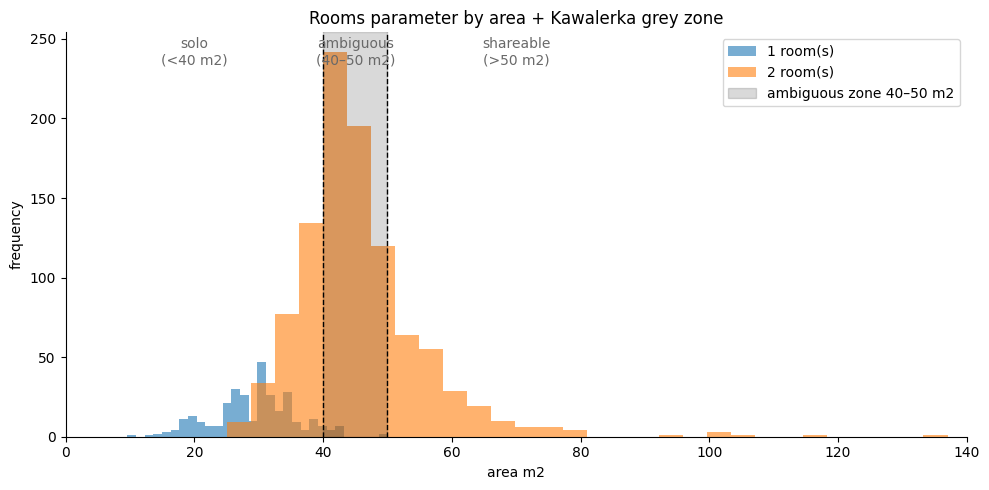

In [127]:
fig, ax = plt.subplots(figsize=(10, 5))

for rooms, group in gdf_listings.groupby("rooms"):
    ax.hist(group["area"], bins=30, alpha=0.6, label=f"{rooms} room(s)")

ax.axvspan(40, 50, alpha=0.15, color="black", label="ambiguous zone 40–50 m2")
ax.axvline(40, color="black", linestyle="--", linewidth=1)
ax.axvline(50, color="black", linestyle="--", linewidth=1)

ax.text(20, ax.get_ylim()[1] * 0.92, "solo\n(<40 m2)", 
        ha="center", fontsize=10, color="dimgrey")
ax.text(45, ax.get_ylim()[1] * 0.92, "ambiguous\n(40–50 m2)", 
        ha="center", fontsize=10, color="dimgrey")
ax.text(70, ax.get_ylim()[1] * 0.92, "shareable\n(>50 m2)", 
        ha="center", fontsize=10, color="dimgrey")

ax.set_xlabel("area m2")
ax.set_xlim(0, 140)
ax.set_ylabel("frequency")
ax.set_title("Rooms parameter by area + Kawalerka grey zone", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

Kawalerka is a type of flat that has a big main room (a combination of a living room, kitchen, etc.) and a small bedroom. Normally such flats are 30-50m2 and are not shareable. Kawalerki are often named "2-room appartments". Flats in the 40-50m2 range were excluded from both categories - their ambiguous classification makes them unsuitable for either solo or sharing analysis. We will still consider all flats under 40m2 solo appartments, to cover 95% of "1-room" and 25th percentile of "2-room", naming them "solo kawalerki". 

In [140]:
gdf_listings["flat_type"] = gdf_listings["area"].apply(
    lambda a: "solo" if a <= 40 else ("shareable" if a >= 50 else "ambiguous")
)
print(gdf_listings["flat_type"].value_counts())

flat_type
solo         627
ambiguous    420
shareable    270
Name: count, dtype: int64


#### Standardizing EPSG

In [141]:
gdf_listings = gdf_listings.to_crs(epsg=2180)
gdf_metro = gdf_metro.to_crs(epsg=2180)
gdf_universities = gdf_universities.to_crs(epsg=2180)
gdf_dorms = gdf_dorms.to_crs(epsg=2180)
gdf_transport = gdf_transport.to_crs(epsg=2180)
gdf_districts = gdf_districts.to_crs(epsg=2180)

print(gdf_listings.crs)
print(gdf_metro.crs)
print(gdf_universities.crs)
print(gdf_dorms.crs)
print(gdf_transport.crs)
print(gdf_districts.crs)

EPSG:2180
EPSG:2180
EPSG:2180
EPSG:2180
EPSG:2180
EPSG:2180


#### Adding price-, size- and location-related measures to the dataset

In [ ]:
gdf_listings["price"] = gdf_listings["total_monthly"]

# calculate distance to city center (Świętokrzyska metro station)
city_center = gdf_metro.loc[gdf_metro["name"] == "Świętokrzyska", "geometry"].iloc[0]

gdf_listings["dist_to_center_m"] = gdf_listings.geometry.distance(city_center).round(0)

# calculate distance to nearest metro station using spatial join
gdf_listings_and_metro = gpd.sjoin_nearest(
    gdf_listings,
    gdf_metro[["geometry"]],       
    how="left",
    distance_col="dist_to_metro_m"
)

gdf_listings = (
    gdf_listings_and_metro
    .sort_values("dist_to_metro_m")
    .drop_duplicates(subset=["title"], keep="first")
    .drop(columns=["index_right"], errors="ignore")
    .round({"dist_to_metro_m": 0})
    .drop(columns=["district_name"], errors="ignore")
)

# find which district each listing is in, we use "within" predicate to ensure we only assign a district if the listing is actually inside it
gdf_listings = gpd.sjoin(
    gdf_listings,
    gdf_districts[["geometry", "district_name"]],
    how="left",
    predicate="within"
).drop(columns=["index_right"], errors="ignore")

# calculate distance to nearest university
gdf_listings = gpd.sjoin_nearest(
    gdf_listings,
    gdf_universities[["geometry"]],
    how="left",
    distance_col="dist_to_uni_m"
).round({"dist_to_uni_m": 0})

# calculate density of listings in a 1km radius
gdf_listings["listings_density"] = (
    gdf_listings.geometry.buffer(1000)
    .apply(lambda x: gdf_listings.within(x).sum())
)

# categorize listings into size categories based on area
gdf_listings["size_category"] = pd.cut(
    gdf_listings["area"],
    bins=[0, 40, 70, 100, 200],
    labels=["small", "medium", "large", "huge"]
)

# calculate log price
gdf_listings["log_price"] = np.log(gdf_listings["price"]).round(3)

# create a binary feature for being within 500m of a metro station
gdf_listings["near_metro"] = (gdf_listings["dist_to_metro_m"] < 500).astype(int)

# calculate average price in the same district
district_avg = gdf_listings.groupby("district_name")["price"].mean()
gdf_listings["district_avg_price"] = gdf_listings["district_name"].map(district_avg).round(2)

# calculate average price of neighboring listings within 500m
gdf_listings["neighbor_price"] = (
    gdf_listings.geometry.buffer(500)
    .apply(lambda x: gdf_listings[gdf_listings.geometry.within(x)]["price"].mean())
)

# function counts how many transit stops are within a given radius of each listing
def count_within_radius_fast(listings, stops, radius_m):
    listings_buffered = listings.copy()
    listings_buffered["geometry"] = listings.geometry.buffer(radius_m)
    
    joined = gpd.sjoin(listings_buffered[["geometry"]], stops[["geometry"]], how="left", predicate="contains")
    return joined.groupby(joined.index).size().reindex(listings.index, fill_value=0)

gdf_listings["transit_stops_500m"] = count_within_radius_fast(gdf_listings, gdf_transport, 500)

# calculate how the price compares to a typical student budget, assuming a certain hourly wage, number of hours worked, and scholarship amount
HOURLY_RATE = 31.40
HOURS_MONTH = 80
SCHOLARSHIP = 800

STUDENT_MONTHLY_BUDGET = round(HOURLY_RATE * HOURS_MONTH + SCHOLARSHIP)

gdf_listings["student_budget_share"] = (gdf_listings["price"] / STUDENT_MONTHLY_BUDGET).round(2)

gdf_uni_proj = gdf_universities.to_crs(gdf_listings.crs)

# this function counts how many unique universities are within a certain radius of each listing
def count_unique_unis_within_radius(listings, unis, radius_m):
    listings_buffered = listings.copy()
    listings_buffered["geometry"] = listings.geometry.buffer(radius_m)
    
    joined = gpd.sjoin(
        listings_buffered[["geometry"]],
        unis[["geometry", "university"]],
        how="left",
        predicate="contains"
    )
    return joined.groupby(joined.index)["university"].nunique().reindex(listings.index, fill_value=0)

gdf_listings["unis_within_3km"] = count_unique_unis_within_radius(gdf_listings, gdf_uni_proj, 3000)

# categorize listings into affordability tiers based on how their price compares to the student budget
gdf_listings["affordability_tier"] = pd.cut(
    gdf_listings["student_budget_share"],
    bins=[0, 0.75, 1.0, 1.25, float("inf")],
    labels=["affordable", "typical", "stretch", "unrealistic"]
)

gdf_listings = gdf_listings[[
    "title",
    "price",
    "area",
    "size_category",
    "rooms",
    "flat_type",
    "district_name",
    "listings_density",
    "price_per_m2",
    "log_price",
    "district_avg_price",
    "student_budget_share",
    "affordability_tier",
    "neighbor_price",
    "dist_to_center_m",
    "dist_to_metro_m",
    "dist_to_uni_m",
    "unis_within_3km",
    "near_metro",
    "transit_stops_500m",
    "geometry",
    "url"
]]

gdf_listings.head()

,title,price,area,size_category,rooms,flat_type,district_name,listings_density,price_per_m2,log_price,...,affordability_tier,neighbor_price,dist_to_center_m,dist_to_metro_m,dist_to_uni_m,unis_within_3km,near_metro,transit_stops_500m,geometry,url
401,Wyjątkowe m2 na przeciwko metra! Bez prowizji!,4684.0,55.00,medium,2,shareable,Bielany,19,67.272727,8.452,...,unrealistic,3649.142857,6594.0,62.0,768.0,3,1,16,POINT (632873.592 492434.097),https://www.otodom.pl/pl/oferta/wyjatkowe-m2-n...
185,2 min. do metra Słodowiec,3520.0,37.00,small,2,solo,Bielany,19,78.378378,8.166,...,stretch,3412.444444,5735.0,64.0,1095.0,3,1,33,POINT (633635.662 491939.874),https://www.otodom.pl/pl/oferta/2-min-do-metra...
1043,"Nowe, ciche mieszkanie na 26 piętrze z pięknym...",5700.0,35.98,small,1,solo,Wola,121,137.576431,8.648,...,unrealistic,6164.187500,1843.0,71.0,784.0,11,1,39,POINT (635355.428 486678.041),https://www.otodom.pl/pl/oferta/nowe-ciche-mie...
164,Centrum 2 pokoje 48m2 Park i Metro!!,4964.0,48.38,medium,2,ambiguous,Śródmieście,22,80.611823,8.510,...,unrealistic,5300.250000,1824.0,73.0,224.0,10,1,54,POINT (637608.325 485605.251),https://www.otodom.pl/pl/oferta/centrum-2-poko...
837,przy Metrze Rondo Daszyńskiego - NOWE- Towarow...,5700.0,34.00,small,2,solo,Wola,120,147.058824,8.648,...,unrealistic,6192.064516,1821.0,75.0,772.0,11,1,41,POINT (635381.902 486669.911),https://www.otodom.pl/pl/oferta/przy-metrze-ro...


## Chapter 3: Student liveability score

#### Filtering for solo appartments

Chapter 3 focuses on solo (<40m2) apartments as the main group of flats for students renting alone, mostly due to the affordability considerations. Effect of sharing a 2-room apartment will be explored in the next chapter, as it requires a different affordability calculation and dataset.

In [143]:
solo_gdf = gdf_listings[gdf_listings["flat_type"] == "solo"]
solo_shareable_gdf = gdf_listings[gdf_listings["flat_type"].isin(["shareable", "solo"])]

gdf_listings = solo_gdf

<Axes: >

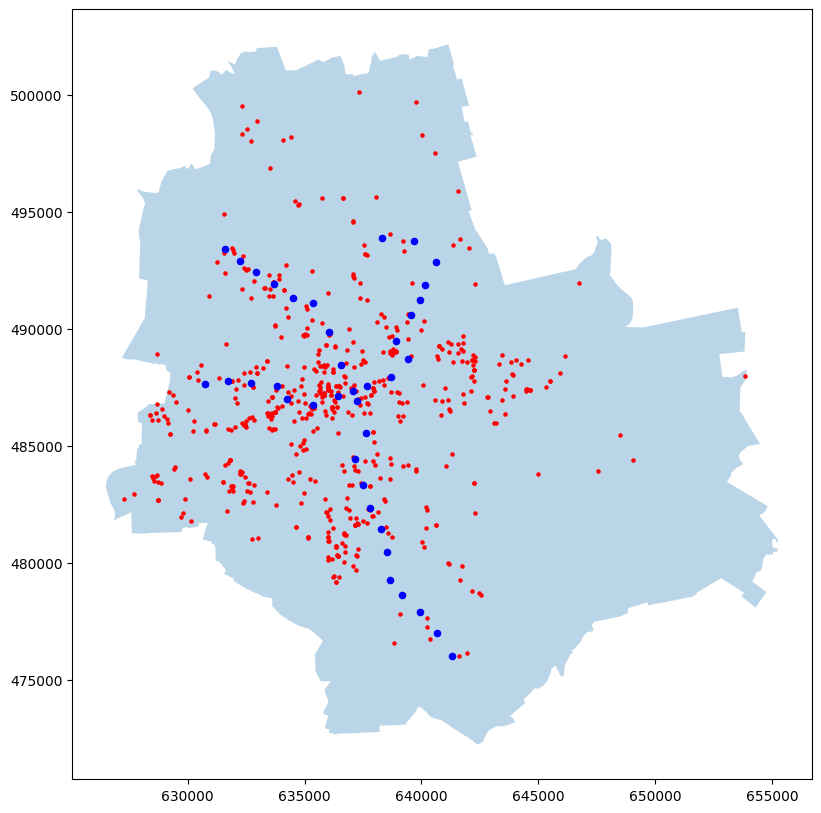

In [ ]:
ax = gdf_districts.plot(figsize=(10,10), alpha=0.3)
gdf_listings.plot(ax=ax, color="red", markersize=5)
gdf_metro.plot(ax=ax, color="blue", markersize=20)

#### Creating a scoring system

To create a score for each appartment encompassing the real student behaviour, the following parameters are utilized:
- Affordability. Parameter uses rent to "Student budget" ratio with constraints, mainly created to punish ratios that exceed 1.0 - prices higher than "Student budget";
- Transit. Parameter combines 2/3 distance to the closest metro station and 1/3 quantity of alternative transit stops within 500m radius;
- Universities. 85% of the parameter is the distance to the closest university building, 15% is the number of university buildings within 3km  from the apartment - used to highlight the flats placed in or just outiside of major student hubs of the city;
- Density. This parameter ensures the recommended area has genuine rental market presence, not an isolated listing.

Final score is a weighted sum: affordability (50%), transit (25%), universities (20%), density (5%). Weights of each parameter are chosen with an affordability focus, with balanced transit and university parameters. This chapter also analyses the scoring sensitivity to other weights.

In [ ]:
scaler = MinMaxScaler()

df = gdf_listings.copy()

# this function assigns a score from 0 to 1 based on how the price compares to the student budget, with a more gradual decline for prices above the budget to avoid harsh cutoffs
def affordability_score(budget_share):
    if budget_share <= 0.75:
        return 1.0
    elif budget_share <= 1.0:
        return 1.0 - ((budget_share - 0.75) / 0.25) * 0.3
    else:
        return 0.7 - ((budget_share - 1.0) * 0.6) 
    
df["affordability_score"] = df["student_budget_share"].apply(affordability_score).clip(0, 1)
df["metro_score"]          = 1 - scaler.fit_transform(df[["dist_to_metro_m"]])
df["transit_score"]        = scaler.fit_transform(df[["transit_stops_500m"]])
df["uni_proximity_score"] = 1 - scaler.fit_transform(df[["dist_to_uni_m"]])
df["uni_breadth_score"]   = scaler.fit_transform(df[["unis_within_3km"]]) 
df["density_score"]        = scaler.fit_transform(df[["listings_density"]])

df["transit_combined"] = (df["metro_score"] * 0.666) + (df["transit_score"] * 0.334)
df["uni_score"] = (df["uni_proximity_score"] * 0.85) + (df["uni_breadth_score"] * 0.15)

df["student_score"] = (
    df["affordability_score"] * 0.50 +   
    df["transit_combined"]    * 0.25 +
    df["uni_score"]           * 0.20 + 
    df["density_score"]       * 0.05     
).round(3)

gdf_listings["student_score"] = df["student_score"]

gdf_listings["student_score"].describe()

count    619.000000
mean       0.657153
std        0.086131
min        0.391000
25%        0.597500
50%        0.659000
75%        0.713000
max        0.895000
Name: student_score, dtype: float64

In [148]:
gdf_listings.nlargest(5, "student_score")[["title", "district_name", "student_score", "url"]]

,title,district_name,student_score,url
1142,Kawalerka mieszkanie Stara Ochota Grójecka 35,Ochota,0.895,https://www.otodom.pl/pl/oferta/kawalerka-mies...
883,Przytulna kawalerka na Woli! Klimatyzacja!,Wola,0.886,https://www.otodom.pl/pl/oferta/przytulna-kawa...
1057,"WYNAJMĘ BEZPOŚREDNIO KAWALERKĘ, WARSZAWA OCHOTA",Ochota,0.876,https://www.otodom.pl/pl/oferta/wynajme-bezpos...
169,Pokój z balkonem w nowoczesnym apartamencie na...,Wola,0.874,https://www.otodom.pl/pl/oferta/pokoj-z-balkon...
388,Ciche przy Marszałkowskiej Epicentrum miasta.M...,Śródmieście,0.870,https://www.otodom.pl/pl/oferta/ciche-przy-mar...


#### Insight 2: Student liveability score and affordability relationship

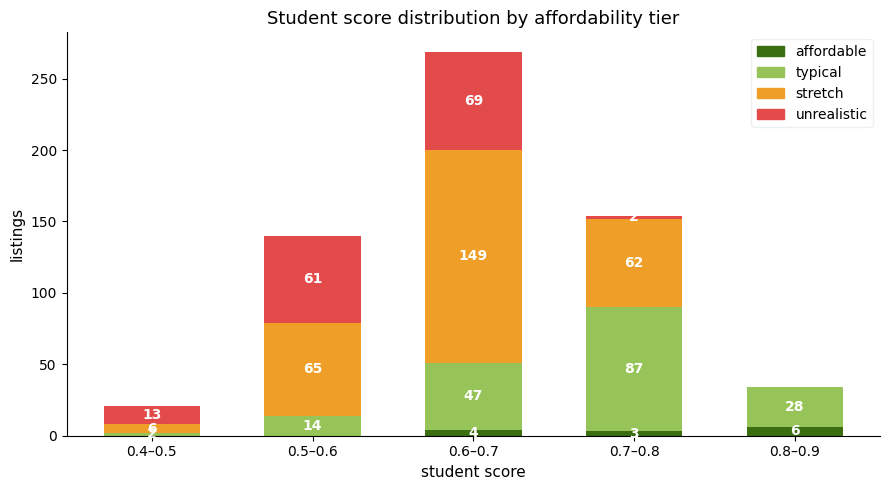

In [147]:
bins = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
bin_labels = ['0.4–0.5', '0.5–0.6', '0.6–0.7', '0.7–0.8', '0.8–0.9']
tiers = ['affordable', 'typical', 'stretch', 'unrealistic']
colors = {'affordable': '#3B6D11', 'typical': '#97C459', 'stretch': '#EF9F27', 'unrealistic': '#E24B4A'}

bin_data = {tier: [] for tier in tiers}
for low, high in zip(bins, bins[1:]):
    bin_df = gdf_listings[
        (gdf_listings["student_score"] >= low) & 
        (gdf_listings["student_score"] < high)
    ]
    counts = bin_df["affordability_tier"].value_counts()
    for tier in tiers:
        bin_data[tier].append(counts.get(tier, 0))

fig, ax = plt.subplots(figsize=(9, 5))
bottoms = np.zeros(len(bin_labels))

for tier in tiers:
    values = np.array(bin_data[tier])
    ax.bar(bin_labels, values, bottom=bottoms, color=colors[tier], label=tier, width=0.6)
    for i, (v, b) in enumerate(zip(values, bottoms)):
        if v > 0:
            ax.text(i, b + v / 2, str(v), ha='center', va='center', 
                   fontsize=10, color='white', fontweight='bold')
    bottoms += values

ax.set_xlabel("student score", fontsize=11)
ax.set_ylabel("listings", fontsize=11)
ax.set_title("Student score distribution by affordability tier", fontsize=13)
ax.legend(handles=[mpatches.Patch(color=colors[t], label=t) for t in tiers],
          loc='upper right', framealpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Across a sample of solo listings, fewer than 2% fall within an affordable budget range for student renting. The majority sit in the stretch or unrealistic tiers, confirming that solo renting in Warsaw operates at or beyond the limits of a typical student budget.

#### Insight 3: Student liveability score map for solo appartments

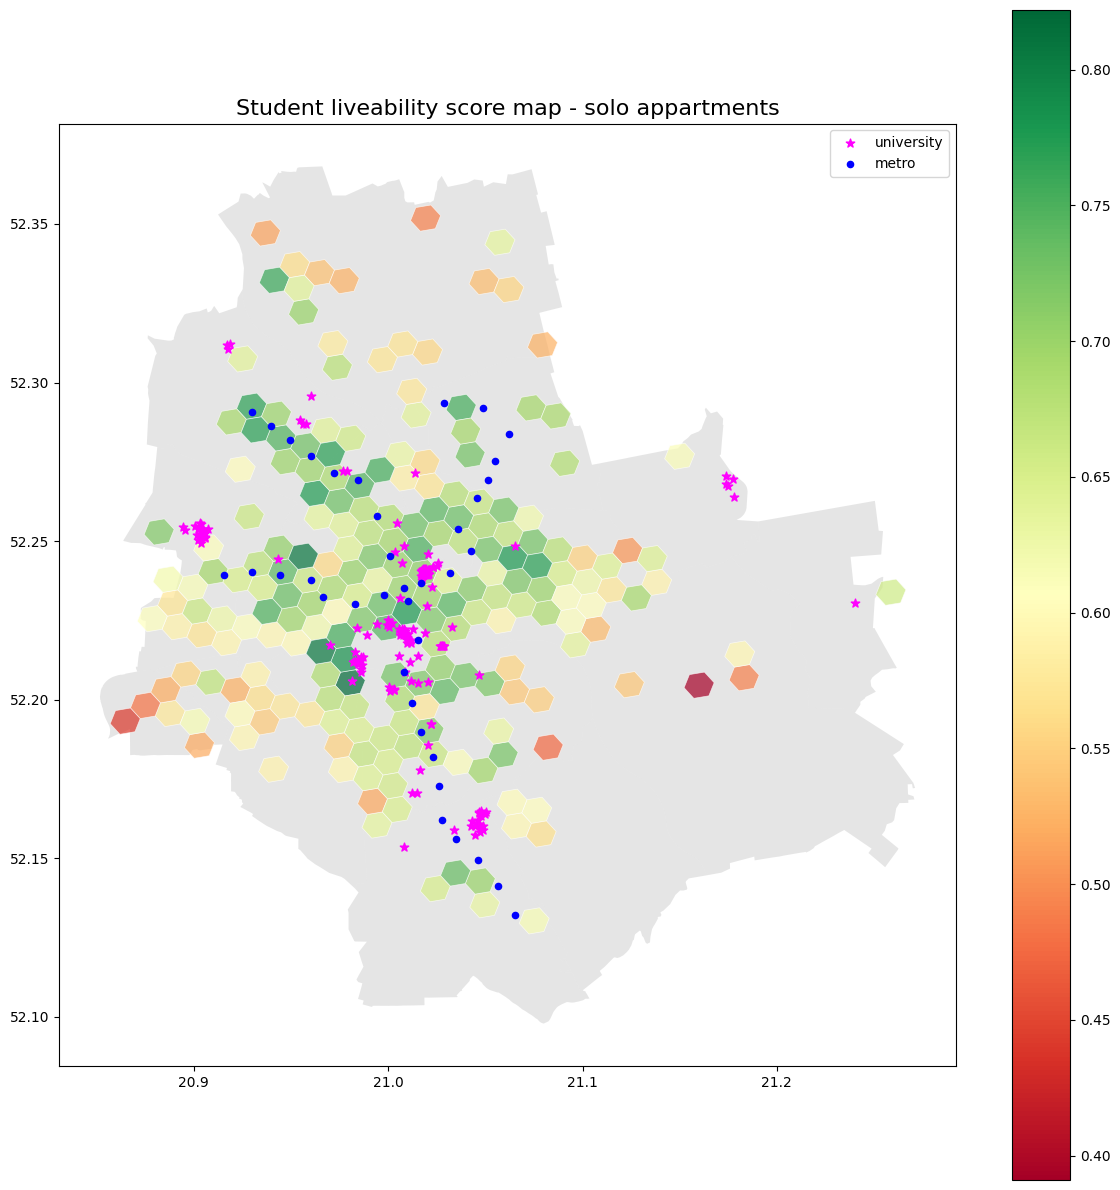

In [149]:
H3_RESOLUTION = 8

gdf_listings["h3_cell"] = gdf_listings.to_crs("EPSG:4326").apply(
    lambda row: h3.latlng_to_cell(row.geometry.y, row.geometry.x, H3_RESOLUTION), axis=1
)

hex_scores = (
    gdf_listings.groupby("h3_cell")
    .agg(
        avg_score=("student_score", "mean"),
        listing_count=("student_score", "count"),
        avg_price=("price", "mean"),
        avg_budget_share=("student_budget_share", "mean")
    )
    .reset_index()
)

def h3_to_polygon(h3_cell):
    coords = h3.cell_to_boundary(h3_cell)
    return Polygon([(lon, lat) for lat, lon in coords])

hex_scores["geometry"] = hex_scores["h3_cell"].apply(h3_to_polygon)
gdf_hex = gpd.GeoDataFrame(hex_scores, geometry="geometry", crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(12, 12))
gdf_districts.to_crs("EPSG:4326").plot(ax=ax, alpha=0.2, color="grey")

gdf_hex.plot(
    ax=ax,
    column="avg_score",
    cmap="RdYlGn",
    legend=True,
    alpha=0.7,
    edgecolor="white",
    linewidth=0.5
)

gdf_universities.to_crs("EPSG:4326").plot(
    ax=ax, color="magenta", markersize=40, marker="*", label="university"
)
gdf_metro.to_crs("EPSG:4326").plot(ax=ax, color="blue", markersize=20, label="metro")

ax.set_title("Student liveability score map - solo appartments", fontsize=16)
ax.legend()
plt.tight_layout()
plt.show()

The map reveals that the highest-scoring areas for solo students concentrate along the metro lines, particularly in the northwest corridor. The cluster of green hexes around Politechnika Warszawska reflects the density of university buildings combined with good metro access and relatively lower prices compared to Śródmieście. Map confirms, Księcia Janusza, Młociny are great non-central alternatives. The cross structure of the metro lines rewards centrally located listings with high transit scores. However, central apartments consistently fall in the stretch or unrealistic affordability tiers - convenience comes at a cost that exceeds most student budgets.

#### Insight 4: Scoring system sensitivity analysis

Stable hex IDs: {'881f5226c9fffff', '881f53c927fffff', '881f53c96bfffff', '881f5226c1fffff', '881f53c93bfffff'}

Score correlations between schemes:
          score_v1  score_v2  score_v3
score_v1     1.000     0.941     0.920
score_v2     0.941     1.000     0.976
score_v3     0.920     0.976     1.000


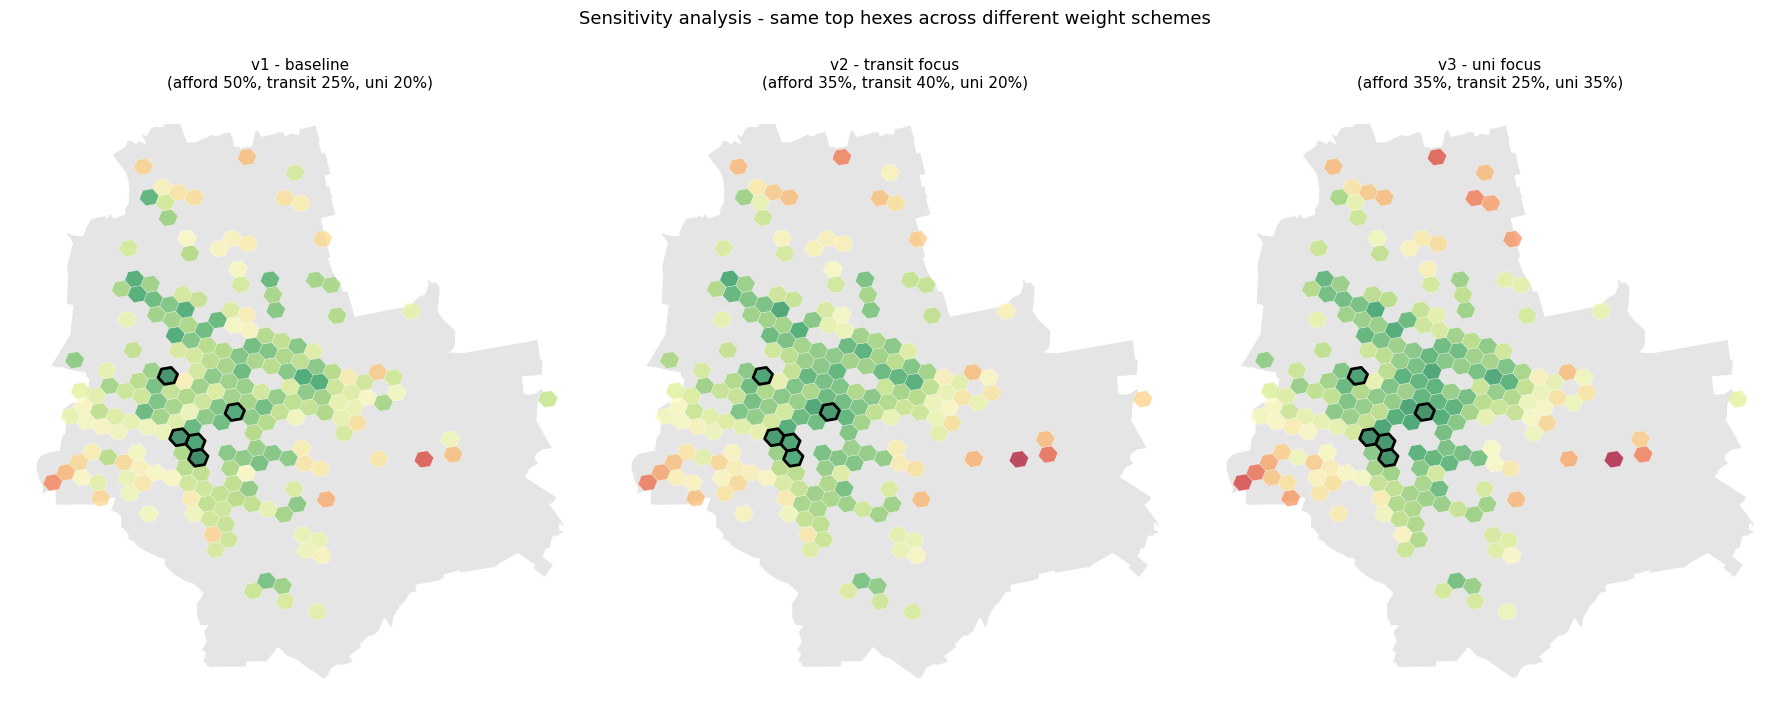

In [ ]:
scaler = MinMaxScaler()
df = gdf_listings.copy()

df["affordability_score"] = df["student_budget_share"].apply(affordability_score).clip(0, 1)
df["metro_score"]         = 1 - scaler.fit_transform(df[["dist_to_metro_m"]])
df["transit_score"]       = scaler.fit_transform(df[["transit_stops_500m"]])
df["uni_proximity_score"] = 1 - scaler.fit_transform(df[["dist_to_uni_m"]])
df["uni_breadth_score"]   = scaler.fit_transform(df[["unis_within_3km"]])
df["density_score"]       = scaler.fit_transform(df[["listings_density"]])

df["transit_combined"] = (df["metro_score"] * 0.666) + (df["transit_score"] * 0.334)
df["uni_score"]        = (df["uni_proximity_score"] * 0.85) + (df["uni_breadth_score"] * 0.15)

# we will test three different weighting schemes to see how they affect the top-ranked hexes: a baseline, a transit-focused one, and a university-focused one
schemes = {
    "v1_baseline": {
        "affordability": 0.50,
        "transit":       0.25,
        "uni":           0.20,
        "density":       0.05,
    },
    "v2_transit_focus": {          
        "affordability": 0.35,
        "transit":       0.40,
        "uni":           0.20,
        "density":       0.05,
    },
    "v3_uni_focus": {              
        "affordability": 0.35,
        "transit":       0.25,
        "uni":           0.35,
        "density":       0.05,
    },
}

for name, w in schemes.items():
    df[f"score_{name}"] = (
        df["affordability_score"] * w["affordability"] +
        df["transit_combined"]    * w["transit"] +
        df["uni_score"]           * w["uni"] +
        df["density_score"]       * w["density"]
    ).round(3)
    gdf_listings[f"score_{name}"] = df[f"score_{name}"]


gdf_wgs = gdf_listings.to_crs("EPSG:4326")
gdf_listings["h3_cell"] = gdf_wgs.apply(
    lambda row: h3.latlng_to_cell(row.geometry.y, row.geometry.x, 8), axis=1
)

# we will consider hexes that appear in the top 10 of all three schemes as "stable" high-scoring areas, which indicates they are good choices regardless of the specific weighting
hex_scores = gdf_listings.groupby("h3_cell").agg(
    score_v1=("score_v1_baseline",    "mean"),
    score_v2=("score_v2_transit_focus","mean"),
    score_v3=("score_v3_uni_focus",   "mean"),
    listing_count=("price",           "count")
).reset_index()

top_v1 = set(hex_scores.nlargest(10, "score_v1")["h3_cell"])
top_v2 = set(hex_scores.nlargest(10, "score_v2")["h3_cell"])
top_v3 = set(hex_scores.nlargest(10, "score_v3")["h3_cell"])

stable_hexes = top_v1 & top_v2 & top_v3
print(f"Stable hex IDs: {stable_hexes}")

print("\nScore correlations between schemes:")
print(hex_scores[["score_v1", "score_v2", "score_v3"]].corr().round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
score_cols = ["score_v1", "score_v2", "score_v3"]
titles = ["v1 - baseline\n(afford 50%, transit 25%, uni 20%)",
          "v2 - transit focus\n(afford 35%, transit 40%, uni 20%)",
          "v3 - uni focus\n(afford 35%, transit 25%, uni 35%)"]

def h3_to_polygon(h3_cell):
    coords = h3.cell_to_boundary(h3_cell)
    return Polygon([(lon, lat) for lat, lon in coords])

hex_scores["geometry"] = hex_scores["h3_cell"].apply(h3_to_polygon)
gdf_hex = gpd.GeoDataFrame(hex_scores, geometry="geometry", crs="EPSG:4326")
districts_wgs = gdf_districts.to_crs("EPSG:4326")

vmin = hex_scores[score_cols].min().min()
vmax = hex_scores[score_cols].max().max()

for ax, col, title in zip(axes, score_cols, titles):
    districts_wgs.plot(ax=ax, alpha=0.2, color="grey")
    gdf_hex.plot(ax=ax, column=col, cmap="RdYlGn",
                 vmin=vmin, vmax=vmax,
                 alpha=0.7, edgecolor="white", linewidth=0.3)
    gdf_hex[gdf_hex["h3_cell"].isin(stable_hexes)].plot(
        ax=ax, facecolor="none", edgecolor="black", linewidth=2, label="stable top hex"
    )
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.suptitle("Sensitivity analysis - same top hexes across different weight schemes",
             fontsize=13, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Sensitivity analysis using score correlation and visual representation of using different weight models proves the objectiveness of the parameters selected. It also opens a possibility of weight adaptation to act as a personalized approach to searching the best listing, explored and realised in the Personalized student liveability scoring engine / flat reccommendation tool. 

## Chapter 4: Sharing strategy

#### Adding shareable appartments

<Axes: >

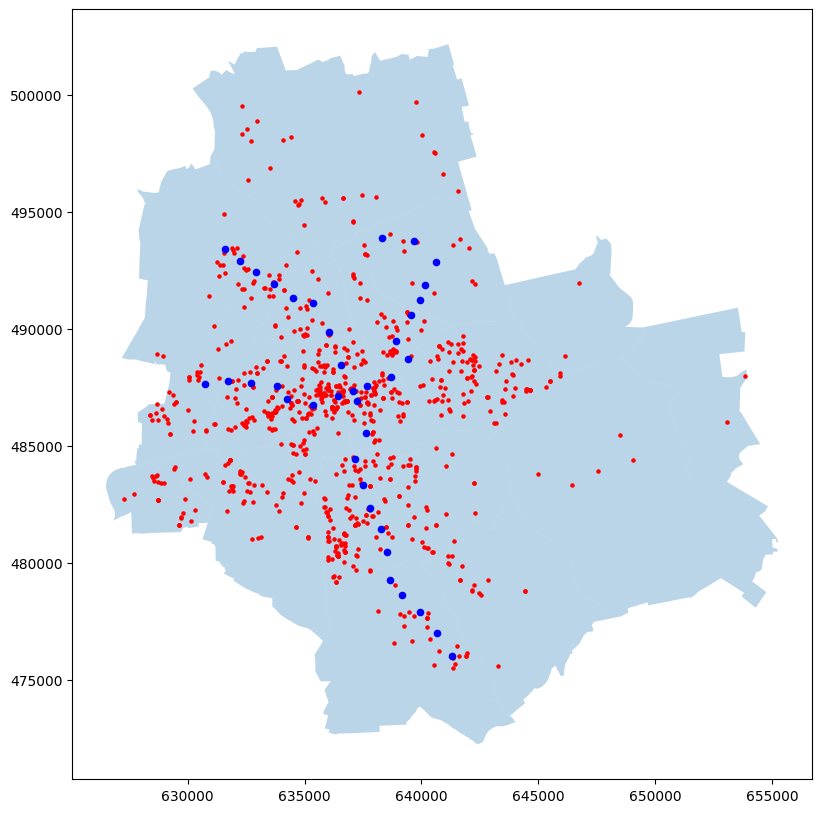

In [151]:
gdf_listings = solo_shareable_gdf

ax = gdf_districts.plot(figsize=(10,10), alpha=0.3)
gdf_listings.plot(ax=ax, color="red", markersize=5)
gdf_metro.plot(ax=ax, color="blue", markersize=20)

#### Insight 5: Solo vs sharable flat score comparison

To present the effect of sharing a 2-room apartment, scoring requires a different affordability calculation as an addition to the existing scoring system. For 2-room shareable (> 50m2) apartments, effective price is divided by two, suggesting an equal split between two students.

In [ ]:
scaler = MinMaxScaler()

df = gdf_listings.copy()

# for shareable flats, we assume the price can be split between two roommates, which makes them more affordable for students, while solo flats are paid in full by one person
df["effective_price"] = df.apply(
    lambda row: row["price"] / 2 if row["flat_type"] == "shareable" else row["price"],
    axis=1
)
df["budget_share_effective"] = df["effective_price"] / STUDENT_MONTHLY_BUDGET

def affordability_score(budget_share):
    if budget_share <= 0.75:
        return 1.0
    elif budget_share <= 1.0:
        return 1.0 - ((budget_share - 0.75) / 0.25) * 0.3
    else:
        return 0.7 - ((budget_share - 1.0) * 0.6)

df["affordability_score"]  = df["budget_share_effective"].apply(affordability_score).clip(0, 1)
df["metro_score"]          = 1 - scaler.fit_transform(df[["dist_to_metro_m"]])
df["transit_score"]        = scaler.fit_transform(df[["transit_stops_500m"]])
df["uni_proximity_score"]  = 1 - scaler.fit_transform(df[["dist_to_uni_m"]])
df["uni_breadth_score"]    = scaler.fit_transform(df[["unis_within_3km"]])
df["density_score"]        = scaler.fit_transform(df[["listings_density"]])

df["transit_combined"] = (df["metro_score"] * 0.666) + (df["transit_score"] * 0.334)
df["uni_score"]        = (df["uni_proximity_score"] * 0.85) + (df["uni_breadth_score"] * 0.15)

df["student_score"] = (
    df["affordability_score"] * 0.50 +
    df["transit_combined"]    * 0.25 +
    df["uni_score"]           * 0.20 +
    df["density_score"]       * 0.05
).round(3)

gdf_listings["effective_price"]     = df["effective_price"]
gdf_listings["budget_share_effective"] = df["budget_share_effective"]
gdf_listings["affordability_score"] = df["affordability_score"]
gdf_listings["student_score"]       = df["student_score"]

print(gdf_listings.groupby("flat_type")["student_score"].describe().round(3))

           count   mean    std    min    25%    50%    75%    max
flat_type                                                        
shareable  267.0  0.772  0.113  0.428  0.734  0.806  0.845  0.940
solo       619.0  0.658  0.086  0.391  0.598  0.660  0.714  0.895


Shareable apartments are scoring much better, with a mean and median more than 0.1 higher than solo flats. Even with a tradeoff of higher variance, it can be clearly stated that flat sharing is a beneficial strategy for students in Warsaw.

## Chapter 5: Housing supply gap

#### Insight 6: Student housing supply map and pie chart

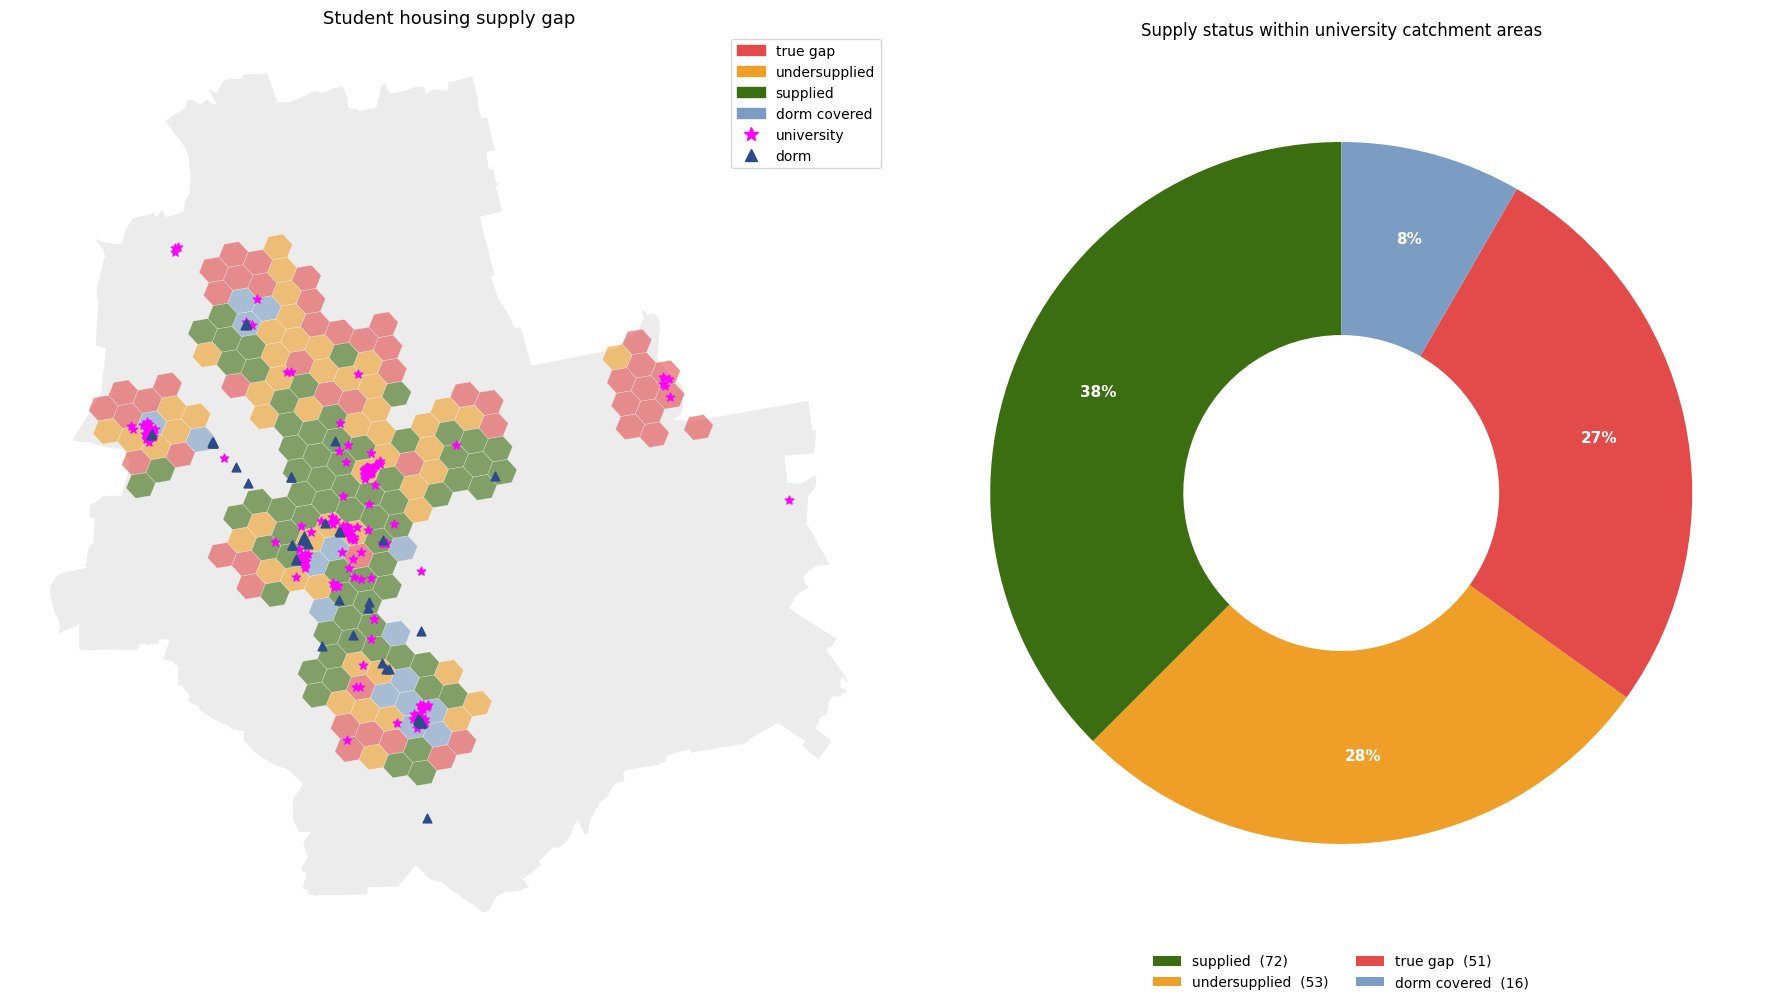

In [ ]:
gdf_uni_proj = gdf_universities[gdf_universities["is_main"] == True].copy()
gdf_uni_proj = gdf_uni_proj.to_crs(gdf_listings.crs)

# we will consider the catchment area of each university to be a 2km radius around its centroid, which is a common threshold for walkability and also captures nearby areas that are still likely to be popular among students of that university
gdf_uni_catchment = gdf_uni_proj.copy()
gdf_uni_catchment["geometry"] = gdf_uni_proj.geometry.centroid.buffer(2000)

warsaw_wgs = gdf_districts.to_crs("EPSG:4326")
minx, miny, maxx, maxy = warsaw_wgs.total_bounds

warsaw_union = warsaw_wgs.union_all()
all_hexes = h3.geo_to_cells(warsaw_union.__geo_interface__, res=8)

def h3_to_polygon(h3_cell):
    coords = h3.cell_to_boundary(h3_cell)
    return Polygon([(lon, lat) for lat, lon in coords])

gdf_grid = gpd.GeoDataFrame(
    {"h3_cell": list(all_hexes)},
    geometry=[h3_to_polygon(h) for h in all_hexes],
    crs="EPSG:4326"
)

if "h3_cell" not in gdf_listings.columns:
    gdf_wgs = gdf_listings.to_crs("EPSG:4326")
    gdf_listings["h3_cell"] = gdf_wgs.apply(
        lambda row: h3.latlng_to_cell(row.geometry.y, row.geometry.x, 8), axis=1
    )

listing_counts = gdf_listings["h3_cell"].value_counts().rename("listing_count")
gdf_grid["listing_count"] = gdf_grid["h3_cell"].map(listing_counts).fillna(0)

gdf_grid_proj = gdf_grid.to_crs(gdf_listings.crs)
gdf_grid_proj["in_catchment"] = gdf_grid_proj.geometry.centroid.apply(
    lambda pt: gdf_uni_catchment.geometry.contains(pt).any()
)

gdf_dorms_proj = gdf_dorms.to_crs(gdf_listings.crs)

gdf_grid_proj["has_dorm_nearby"] = gdf_grid_proj.geometry.centroid.apply(
    lambda pt: gdf_dorms_proj.geometry.distance(pt).min() < 1000
)

def classify_hex(row):
    if not row["in_catchment"]:
        return "outside catchment"
    elif row["listing_count"] == 0 and not row["has_dorm_nearby"]:
        return "true gap"
    elif row["listing_count"] == 0 and row["has_dorm_nearby"]:
        return "dorm covered"
    elif row["listing_count"] <= 2:
        return "undersupplied"
    else:
        return "supplied"

gdf_grid_proj["supply_status"] = gdf_grid_proj.apply(classify_hex, axis=1)

hex_colors = {
    "true gap":     "#E24B4A",
    "dorm covered": "#7B9DC4",
    "undersupplied":"#EF9F27",
    "supplied":     "#3B6D11",
}

fig, (ax_map, ax_pie) = plt.subplots(1, 2, figsize=(18, 10))

gdf_districts.to_crs("EPSG:4326").plot(ax=ax_map, alpha=0.15, color="grey")

for status, color in hex_colors.items():
    subset = gdf_grid_proj[gdf_grid_proj["supply_status"] == status].to_crs("EPSG:4326")
    if status == "outside catchment":
        continue
    subset.plot(ax=ax_map, color=color, alpha=0.6, edgecolor="white",
                linewidth=0.3, label=status)

gdf_universities.to_crs("EPSG:4326").plot(
    ax=ax_map, color="magenta", markersize=40, marker="*", label="university"
)
gdf_dorms_proj.to_crs("EPSG:4326").plot(
    ax=ax_map, color="#2C4B8A", markersize=40, marker="^", label="dorm", zorder=5
)

legend_patches = [
    mpatches.Patch(color="#E24B4A", label="true gap"),
    mpatches.Patch(color="#EF9F27", label="undersupplied"),
    mpatches.Patch(color="#3B6D11", label="supplied"),
    mpatches.Patch(color="#7B9DC4", label="dorm covered"),
]
uni_handle  = mlines.Line2D([], [], color="magenta", marker="*", linestyle="None", markersize=10, label="university")
dorm_handle = mlines.Line2D([], [], color="#2C4B8A", marker="^", linestyle="None", markersize=8,  label="dorm")
ax_map.legend(handles=legend_patches + [uni_handle, dorm_handle])
ax_map.set_title("Student housing supply gap", fontsize=13)
ax_map.axis("off")

status_counts = (
    gdf_grid_proj[gdf_grid_proj["in_catchment"]]
    ["supply_status"].value_counts()
)

pie_labels = ["supplied", "undersupplied", "true gap", "dorm covered"]
pie_sizes  = [status_counts.get(l, 0) for l in pie_labels]
pie_colors = ["#3B6D11", "#EF9F27", "#E24B4A", "#7B9DC4"]

wedges, texts, autotexts = ax_pie.pie(
    pie_sizes,
    labels=None,
    colors=pie_colors,
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops={"width": 0.55, "linewidth": 0},
    pctdistance=0.75
)

for t in autotexts:
    t.set_fontsize(11)
    t.set_color("white")
    t.set_fontweight("bold")

ax_pie.legend(
    wedges, [f"{l}  ({s})" for l, s in zip(pie_labels, pie_sizes)],
    loc="lower center", bbox_to_anchor=(0.5, -0.08),
    ncol=2, fontsize=10, frameon=False
)
ax_pie.set_title("Supply status within university catchment areas", fontsize=12, pad=14)

plt.tight_layout()
plt.show()

More than half of university catchment hexes have inadequate private rental supply (undersupplied + true gap combined). Only 1/3 are properly served by the market, and dorms cover just 8%.